# Daily Challenge: Classifying Handwritten Digits with CNNs

## Load the MNIST Dataset

In [1]:
from keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Print shapes
print("x_train shape:", x_train.shape)  # (60000, 28, 28)
print("y_train shape:", y_train.shape)  # (60000,)
print("x_test shape:", x_test.shape)    # (10000, 28, 28)
print("y_test shape:", y_test.shape)    # (10000,)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


## Preprocess Data for Fully Connected Neural Network

In [3]:
from keras.utils import to_categorical

# Flatten images for FCNN
x_train_fc = x_train.reshape(x_train.shape[0], 28*28)
x_test_fc = x_test.reshape(x_test.shape[0], 28*28)

# Normalize
x_train_fc = x_train_fc.astype('float32') / 255
x_test_fc = x_test_fc.astype('float32') / 255

# One-hot encode labels
y_train_fc = to_categorical(y_train, 10)
y_test_fc = to_categorical(y_test, 10)

## Build and Train a Fully Connected Neural Network

In [4]:
from keras.models import Sequential
from keras.layers import Dense

# Create model
fc_model = Sequential()
fc_model.add(Dense(128, input_shape=(784,), activation='relu'))
fc_model.add(Dense(64, activation='relu'))
fc_model.add(Dense(10, activation='softmax'))  # 10 classes

# Compile model
fc_model.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# Train model
fc_history = fc_model.fit(x_train_fc, y_train_fc,
                          validation_split=0.1,
                          epochs=10,
                          batch_size=128,
                          verbose=2)

# Evaluate
fc_score = fc_model.evaluate(x_test_fc, y_test_fc, verbose=0)
print("FCNN Test Accuracy:", fc_score[1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
422/422 - 7s - 16ms/step - accuracy: 0.8977 - loss: 0.3564 - val_accuracy: 0.9608 - val_loss: 0.1445
Epoch 2/10
422/422 - 4s - 10ms/step - accuracy: 0.9582 - loss: 0.1439 - val_accuracy: 0.9715 - val_loss: 0.1022
Epoch 3/10
422/422 - 2s - 4ms/step - accuracy: 0.9708 - loss: 0.0998 - val_accuracy: 0.9740 - val_loss: 0.0911
Epoch 4/10
422/422 - 2s - 4ms/step - accuracy: 0.9770 - loss: 0.0764 - val_accuracy: 0.9742 - val_loss: 0.0907
Epoch 5/10
422/422 - 2s - 4ms/step - accuracy: 0.9821 - loss: 0.0602 - val_accuracy: 0.9783 - val_loss: 0.0759
Epoch 6/10
422/422 - 2s - 4ms/step - accuracy: 0.9856 - loss: 0.0482 - val_accuracy: 0.9778 - val_loss: 0.0787
Epoch 7/10
422/422 - 2s - 4ms/step - accuracy: 0.9876 - loss: 0.0391 - val_accuracy: 0.9792 - val_loss: 0.0748
Epoch 8/10
422/422 - 3s - 7ms/step - accuracy: 0.9900 - loss: 0.0325 - val_accuracy: 0.9802 - val_loss: 0.0761
Epoch 9/10
422/422 - 4s - 9ms/step - accuracy: 0.9924 - loss: 0.0260 - val_accuracy: 0.9790 - val_loss: 0.0784

## Preprocess Data for Convolutional Neural Network

In [5]:
# Reshape for Conv2D: (samples, height, width, channels)
x_train_cnn = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test_cnn = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Normalize pixel values
x_train_cnn = x_train_cnn.astype('float32') / 255
x_test_cnn = x_test_cnn.astype('float32') / 255

# One-hot encode labels for CNN
y_train_cnn = to_categorical(y_train, 10)
y_test_cnn = to_categorical(y_test, 10)

## Build and Train a Convolutional Neural Network

In [6]:
from keras.layers import Conv2D, MaxPooling2D, Flatten

# Create CNN model
cnn_model = Sequential()
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(10, activation='softmax'))

# Compile model
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Train model
cnn_history = cnn_model.fit(x_train_cnn, y_train_cnn,
                            validation_split=0.1,
                            epochs=10,
                            batch_size=128,
                            verbose=2)

# Evaluate
cnn_score = cnn_model.evaluate(x_test_cnn, y_test_cnn, verbose=0)
print("CNN Test Accuracy:", cnn_score[1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
422/422 - 44s - 104ms/step - accuracy: 0.9348 - loss: 0.2244 - val_accuracy: 0.9813 - val_loss: 0.0616
Epoch 2/10
422/422 - 38s - 91ms/step - accuracy: 0.9808 - loss: 0.0637 - val_accuracy: 0.9863 - val_loss: 0.0493
Epoch 3/10
422/422 - 39s - 92ms/step - accuracy: 0.9865 - loss: 0.0443 - val_accuracy: 0.9850 - val_loss: 0.0492
Epoch 4/10
422/422 - 41s - 97ms/step - accuracy: 0.9896 - loss: 0.0342 - val_accuracy: 0.9887 - val_loss: 0.0364
Epoch 5/10
422/422 - 37s - 87ms/step - accuracy: 0.9917 - loss: 0.0265 - val_accuracy: 0.9877 - val_loss: 0.0389
Epoch 6/10
422/422 - 37s - 87ms/step - accuracy: 0.9932 - loss: 0.0208 - val_accuracy: 0.9897 - val_loss: 0.0385
Epoch 7/10
422/422 - 41s - 96ms/step - accuracy: 0.9943 - loss: 0.0176 - val_accuracy: 0.9895 - val_loss: 0.0384
Epoch 8/10
422/422 - 37s - 87ms/step - accuracy: 0.9951 - loss: 0.0149 - val_accuracy: 0.9918 - val_loss: 0.0349
Epoch 9/10
422/422 - 41s - 97ms/step - accuracy: 0.9963 - loss: 0.0116 - val_accuracy: 0.9902 -

## Compare Performance

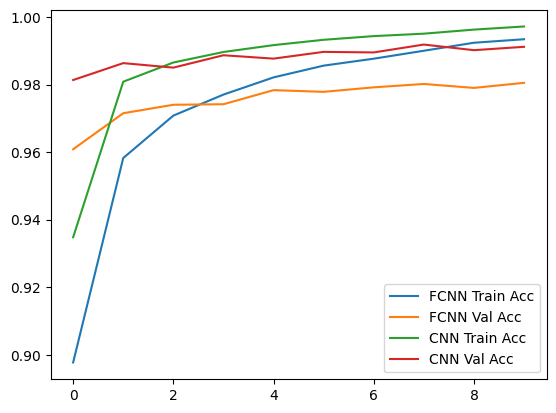

In [7]:
import matplotlib.pyplot as plt

plt.plot(fc_history.history['accuracy'], label='FCNN Train Acc')
plt.plot(fc_history.history['val_accuracy'], label='FCNN Val Acc')
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.legend()
plt.show()